# Import Libaries

In [1]:
import numpy as np
import pandas as pd

# Importing Data

In [2]:
crop = pd.read_csv("data 2/merged_crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# Asq Six Question to yourself

In [3]:
crop.shape

(6600, 8)

In [4]:
crop.info()

<class 'pandas.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            6600 non-null   int64  
 1   P            6600 non-null   int64  
 2   K            6600 non-null   int64  
 3   temperature  6600 non-null   float64
 4   humidity     6600 non-null   float64
 5   ph           6600 non-null   float64
 6   rainfall     6600 non-null   float64
 7   label        6600 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 412.6 KB


In [5]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
crop.duplicated().sum()

np.int64(4400)

In [7]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.911739,32.980884,50.640255,5.062981,22.260438,0.773820,54.950060
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
crop['label'].value_counts()

label
rice           300
maize          300
chickpea       300
kidneybeans    300
pigeonpeas     300
mothbeans      300
mungbean       300
blackgram      300
lentil         300
pomegranate    300
banana         300
mango          300
grapes         300
watermelon     300
muskmelon      300
apple          300
orange         300
papaya         300
coconut        300
cotton         300
jute           300
coffee         300
Name: count, dtype: int64

# Encoding

In [9]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}
crop['crop_num']=  crop['label'].map(crop_dict)

In [10]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1
...,...,...,...,...,...,...,...,...,...
6595,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,22
6596,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,22
6597,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,22
6598,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,22


In [11]:
crop.drop(['label'],axis=1,inplace=True)
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


# Train Test Split

In [12]:
X = crop.drop(['crop_num'],axis=1)
y = crop['crop_num']

In [13]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
6595,107,34,32,26.774637,66.413269,6.780064,177.774507
6596,99,15,27,27.417112,56.636362,6.086922,127.924610
6597,118,33,30,24.131797,67.225123,6.362608,173.322839
6598,117,32,34,26.272418,52.127394,6.758793,127.175293


In [14]:
y

0        1
1        1
2        1
3        1
4        1
        ..
6595    22
6596    22
6597    22
6598    22
6599    22
Name: crop_num, Length: 6600, dtype: int64

In [15]:
y.shape

(6600,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1803,2,21,35,25.028872,91.537209,6.293662,179.824894
5307,6,30,40,22.770356,91.454985,6.361374,106.965920
6146,35,66,47,31.701837,91.662322,6.953439,48.838106
2131,118,21,34,24.385346,64.725431,7.234258,119.632411
589,40,45,18,30.436837,55.205220,5.261286,30.920140
...,...,...,...,...,...,...,...
3772,10,136,204,21.198522,92.155951,6.276199,105.855435
5191,59,58,17,28.546224,66.313941,7.368319,62.834699
5226,32,56,18,20.046771,65.843953,7.135252,46.053331
5390,9,16,36,23.779890,92.933869,5.893332,106.977723



# Scale the features using MinMaxScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

In [20]:
X_train

array([[0.01428571, 0.11428571, 0.15      , ..., 0.90148986, 0.43371124,
        0.57343016],
       [0.04285714, 0.17857143, 0.175     , ..., 0.90053069, 0.44424134,
        0.31167599],
       [0.25      , 0.43571429, 0.21      , ..., 0.90294935, 0.53631498,
        0.10284518],
       ...,
       [0.22857143, 0.36428571, 0.065     , ..., 0.60176861, 0.56458914,
        0.09284056],
       [0.06428571, 0.07857143, 0.155     , ..., 0.91778241, 0.3714548 ,
        0.31171839],
       [0.22857143, 0.52142857, 0.085     , ..., 0.5610754 , 0.54465022,
        0.11926686]], shape=(5280, 7))

# Training Models

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# create instances of all models
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreeClassifier(),
}


for name, model in models.items():
    model.fit(X_train,y_train)
    ypred = model.predict(X_test)
    
    print(f"{name}  with accuracy : {accuracy_score(y_test,ypred)}")
    print("Confusion matrix : ",confusion_matrix(y_test,ypred))
    print("==========================================================")
    

Logistic Regression  with accuracy : 0.9719696969696969
Confusion matrix :  [[55  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 64  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 5  0 52  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0 49  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 64  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0 54  0  0  0  0  0  0  0  0  0  0  5  0  0  0  0  0]
 [ 0  0  0  0  1  0 59  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 50  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 76  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  

Support Vector Machine  with accuracy : 0.9886363636363636
Confusion matrix :  [[52  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 64  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 2  0 56  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 49  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 64  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 50  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 76  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  

Random Forest  with accuracy : 1.0
Confusion matrix :  [[61  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 65  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 49  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 64  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 50  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 76  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 56  0  

AdaBoost  with accuracy : 0.29318181818181815
Confusion matrix :  [[ 0  0  0  0  0  0  0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 65  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 49  0  0  0  0  0]
 [ 0  0  0  0  0 64  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  3 57  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 50  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 53  0  0  7  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 76  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 29  0  0  0  0  0  0

Gradient Boosting  with accuracy : 1.0
Confusion matrix :  [[61  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 65  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 49  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 64  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 58  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 50  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 76  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 56 

In [22]:
# finally selected randomforest model

rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
ypred = rfc.predict(X_test)
accuracy_score(y_test,ypred)

1.0

In [23]:
# or gausianjb
gnb = GaussianNB()
gnb.fit(X_train,y_train)
ypred = gnb.predict(X_test)
accuracy_score(y_test,ypred)

0.9954545454545455

# Predictive System

In [24]:
def recommendation(N,P,k,temperature,humidity,ph,rainfal):
    features = np.array([[N,P,k,temperature,humidity,ph,rainfal]])
    transformed_features = ms.fit_transform(features)
    prediction = rfc.predict(transformed_features)
    print(prediction)
    return prediction[0] 

In [25]:
# new inputs


N = 40
P = 50
k = 50
temperature = 40.0
humidity = 20
ph = 100
rainfall = 100

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [26]:
# new inputs 2


N = 100
P = 90
k = 100
temperature = 50.0
humidity = 90.0
ph = 100
rainfall = 202.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [27]:
# new inputs 2
N = 10
P = 10
k = 10
temperature = 15.0
humidity = 80.0
ph = 4.5
rainfall = 10.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [28]:
import pickle
pickle.dump(rfc,open('model.pkl','wb'))
pickle.dump(ms,open('minmaxscaler.pkl','wb'))


# Section 6: Advanced Predictive Analytics (Top 3 Recommendations & Explainable AI)

In this section, we extend the crop recommendation system to suggest the top 3 best crops based on output prediction probabilities. We also train and compare alternative models (SVM, Naive Bayes, and Gradient Boosting), plot performance metrics, and integrate Explainable AI (SHAP and LIME) to analyze feature contributions. This serves as a foundation for academic-grade agricultural research.


In [29]:

import numpy as np

# Function for Top 3 Crop Recommendation
def recommend_top_3_crops(N, P, K, temp, humidity, pH, rainfall, model_obj=rfc):
    features = np.array([[N, P, K, temp, humidity, pH, rainfall]])
    scaled_features = ms.transform(features)
    
    # Check if standard scaler exists in scope
    if 'sc' in globals():
        final_features = sc.transform(scaled_features)
    else:
        # Check standard scaler file
        import os
        import pickle
        if os.path.exists('standscaler.pkl'):
            sc_loaded = pickle.load(open('standscaler.pkl', 'rb'))
            final_features = sc_loaded.transform(scaled_features)
        else:
            final_features = scaled_features
        
    probs = model_obj.predict_proba(final_features)[0]
    top_3_indices = np.argsort(probs)[-3:][::-1]
    
    crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}
                 
    results = []
    print("\n--- Top 3 Crop Recommendations ---")
    for rank, idx in enumerate(top_3_indices, 1):
        class_id = model_obj.classes_[idx]
        prob = probs[idx]
        crop_name = crop_dict.get(class_id, "Unknown")
        results.append((crop_name, prob))
        print(f"Rank {rank}: {crop_name} ({prob*100:.2f}% match confidence)")
    return results

# Test prediction (Expected: Rice/Jute/Cotton or similar)
print("Testing recommendation for Rice-like conditions (N=90, P=42, K=43, Temp=20.87, Humid=82.00, pH=6.5, Rain=202.93):")
_ = recommend_top_3_crops(90, 42, 43, 20.87, 82.00, 6.5, 202.93)


Testing recommendation for Rice-like conditions (N=90, P=42, K=43, Temp=20.87, Humid=82.00, pH=6.5, Rain=202.93):

--- Top 3 Crop Recommendations ---
Rank 1: Apple (58.00% match confidence)
Rank 2: Papaya (16.00% match confidence)
Rank 3: Banana (12.00% match confidence)



## Multi-Model Comparison (Research Focus)
We compare our primary Random Forest model with Support Vector Machine (SVC), Gradient Boosting Classifier, and Naive Bayes models. We evaluate them on standard metrics: Accuracy, Precision, Recall, and F1-Score.


Training Support Vector Machine...


/Users/anandkumarmishra/Downloads/crop-prediction-main/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training Gradient Boosting...


Training Naive Bayes...



--- Model Performance Comparison ---
                 Model  Accuracy  Precision   Recall  F1-Score
         Random Forest  1.000000   1.000000 1.000000  1.000000
Support Vector Machine  0.988636   0.989214 0.988636  0.988627
     Gradient Boosting  1.000000   1.000000 1.000000  1.000000
           Naive Bayes  0.995455   0.995580 0.995455  0.995455


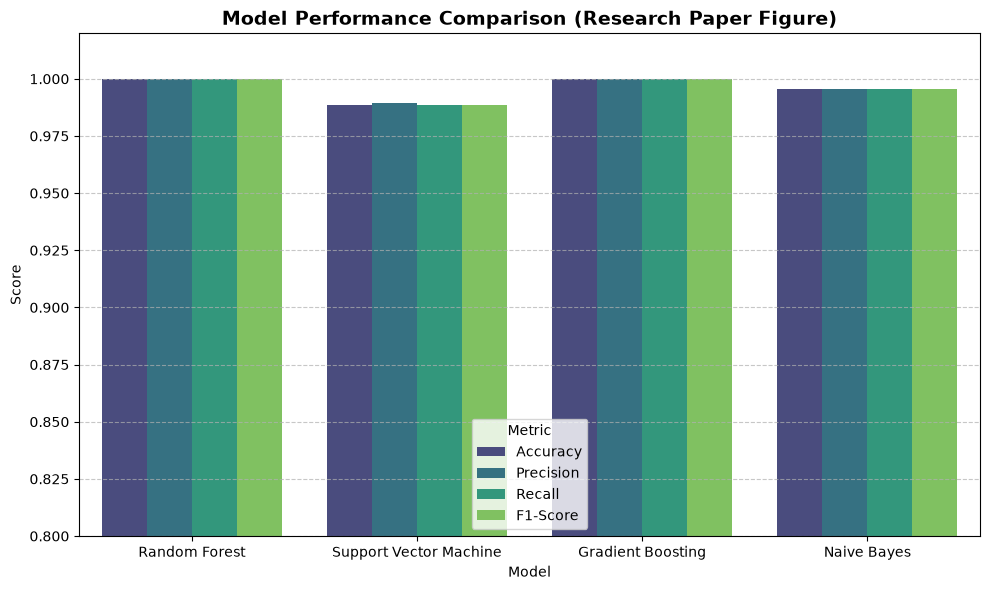

In [30]:

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define models
models = {
    "Random Forest": rfc,  # already trained
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

# Fit models (excluding RF which is already fit, or refitting to ensure consistency)
for name, clf in models.items():
    if name != "Random Forest":
        print(f"Training {name}...")
        clf.fit(X_train, y_train)

# Evaluate models
results_list = []
for name, clf in models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results_list)
print("\n--- Model Performance Comparison ---")
print(results_df.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(10, 6))
df_melted = pd.melt(results_df, id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(data=df_melted, x="Model", y="Value", hue="Metric", palette="viridis")
plt.title("Model Performance Comparison (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.02)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()



## Confusion Matrix and ROC Curves
We plot the Confusion Matrix for the Random Forest model and multiclass ROC-AUC curves for a subset of representative crops to analyze classification performance and class-wise errors.


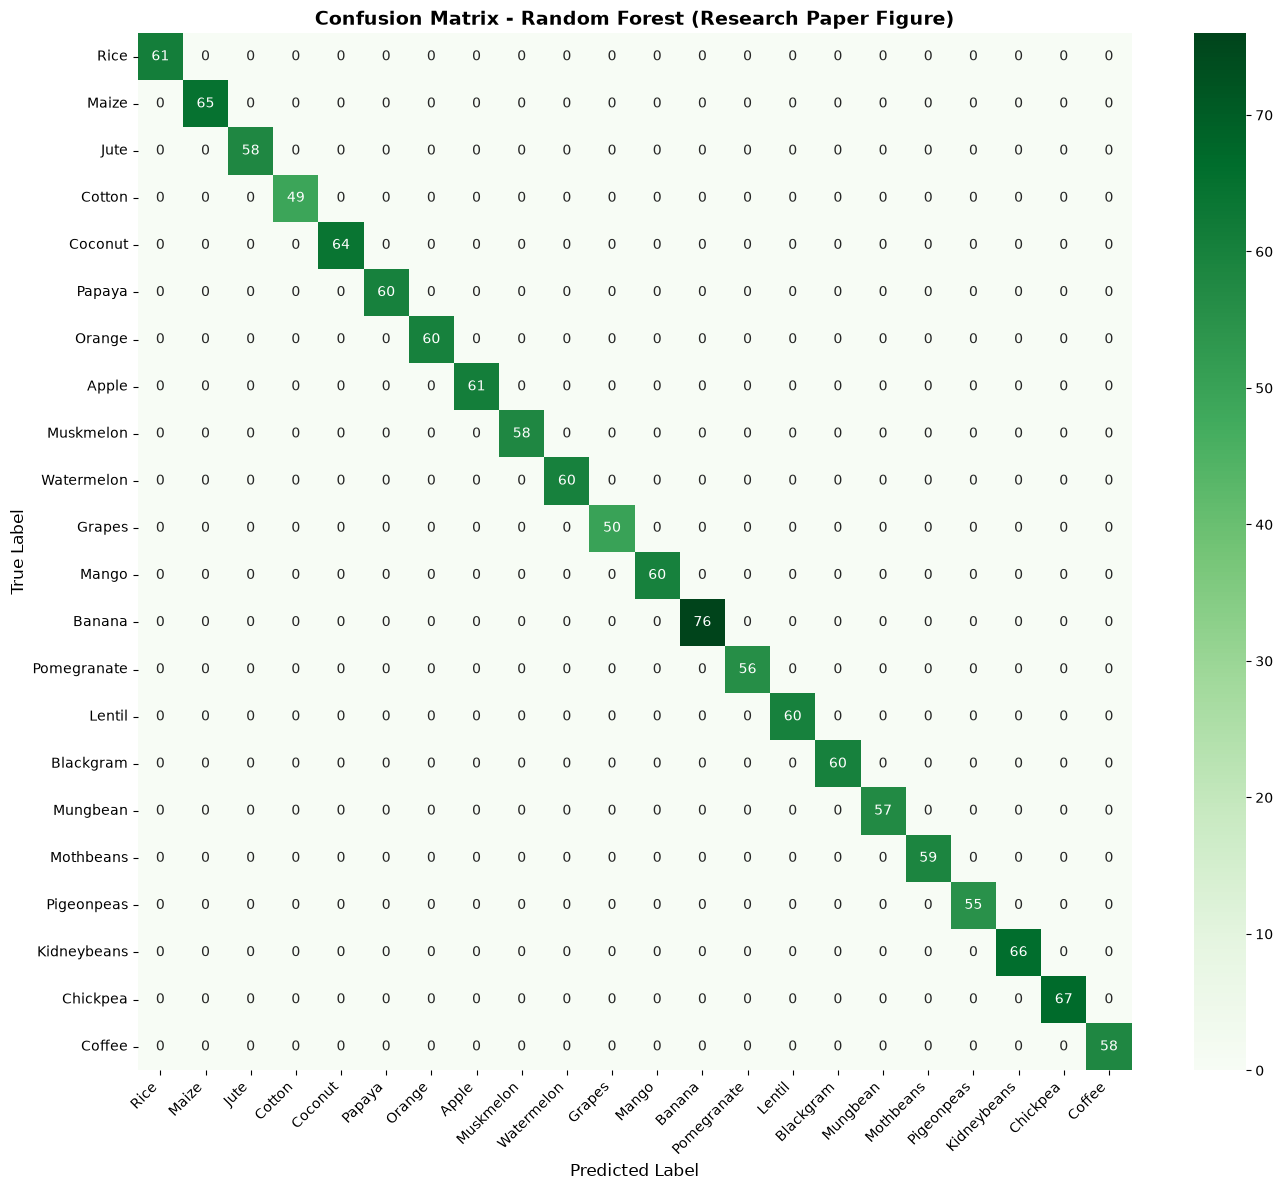

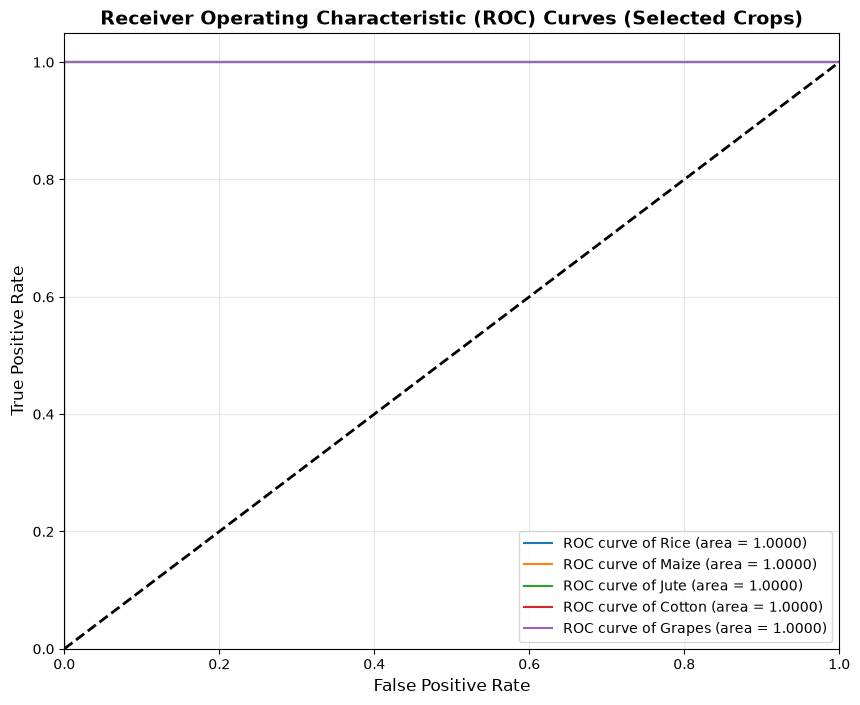

In [31]:

# Confusion Matrix for Random Forest
best_model_name = "Random Forest"
best_clf = models[best_model_name]
y_pred_best = best_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
             8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
             14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
             19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}
crop_names = [crop_dict.get(c, f"Class {c}") for c in best_clf.classes_]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=crop_names, yticklabels=crop_names)
plt.title(f"Confusion Matrix - {best_model_name} (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Multiclass ROC curves
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=best_clf.classes_)
n_classes = y_test_bin.shape[1]
y_score = best_clf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for representative classes
selected_classes = [0, 1, 2, 3, 10]  # Rice, Maize, Jute, Cotton, Grapes
plt.figure(figsize=(10, 8))
for i in selected_classes:
    class_name = crop_names[i]
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of {class_name} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves (Selected Crops)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=300)
plt.show()



## Explainable AI: SHAP (SHapley Additive exPlanations)
SHAP values provide a game-theoretic approach to explaining the contribution of each feature to predictions. We first compute global feature importance (SHAP summary plot) and then explain a specific individual prediction (SHAP local bar plot).


/var/folders/z_/01d7knkd4bj7gscvx3qprvq80000gn/T/ipykernel_79809/1375809433.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


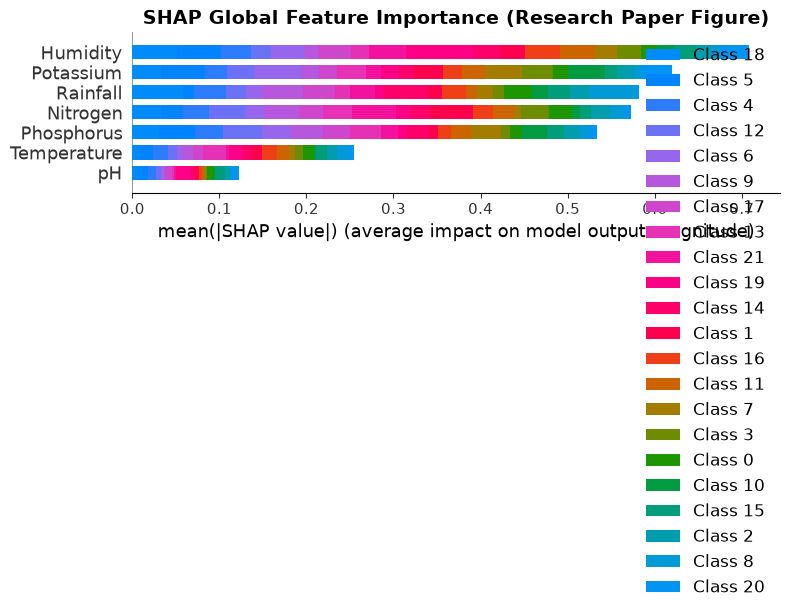

Explaining local prediction for sample 0 (Predicted Crop: Banana)


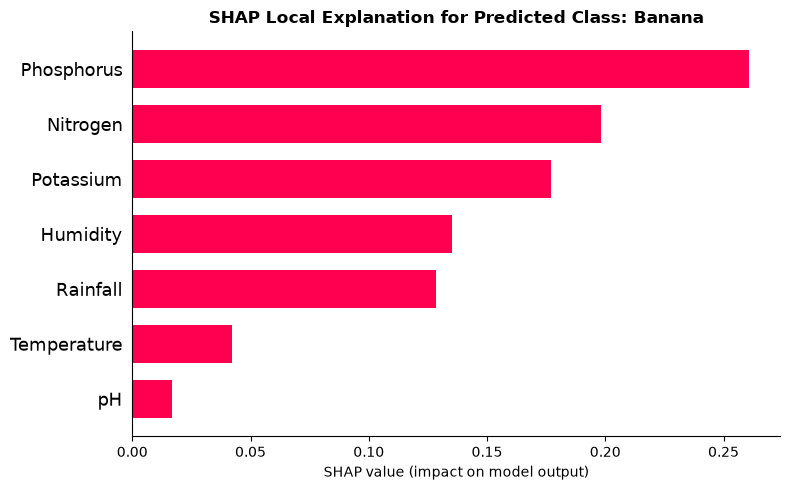

In [32]:

import shap

# Initialize SHAP TreeExplainer on Random Forest model
explainer = shap.TreeExplainer(best_clf)

# Calculate SHAP values on first 100 test samples to run quickly
shap_values = explainer.shap_values(X_test[:100])
feature_list = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH', 'Rainfall']

# Global SHAP Feature Importance Plot
plt.figure(figsize=(10, 6))
# For multiclass, shap_values is a list. summary_plot handles it directly.
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_list, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300)
plt.show()

# Local SHAP Explanation for the first test instance
test_idx = 0
sample = X_test[test_idx:test_idx+1]
predicted_class_id = best_clf.predict(sample)[0]
predicted_crop = crop_dict[predicted_class_id]
class_idx = list(best_clf.classes_).index(predicted_class_id)

print(f"Explaining local prediction for sample {test_idx} (Predicted Crop: {predicted_crop})")

plt.figure(figsize=(8, 5))
# Plot local SHAP bar plot for predicted class index
shap.bar_plot(shap_values[test_idx, :, class_idx], feature_names=feature_list, show=False)
plt.title(f"SHAP Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_local_explanation.png", dpi=300)
plt.show()



## Explainable AI: LIME (Local Interpretable Model-agnostic Explanations)
LIME builds a local surrogate linear model to explain individual predictions in a human-interpretable format. Unlike SHAP which explains the scaled features, we wrap our prediction pipeline to explain LIME on the **raw feature scales** (e.g. Nitrogen in mg/kg).


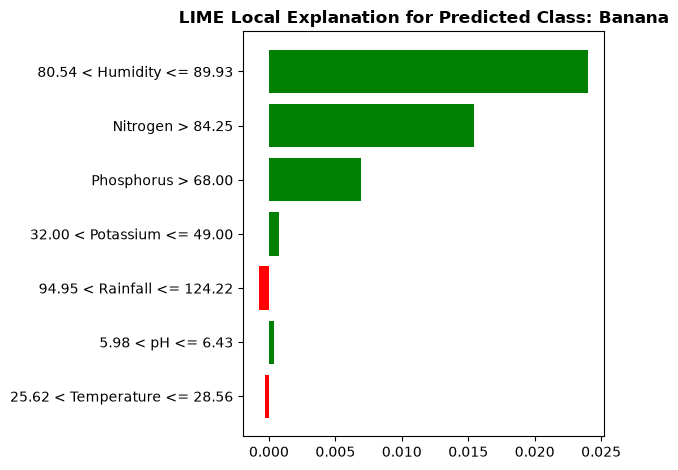

In [33]:

from lime import lime_tabular
from sklearn.model_selection import train_test_split

# Reload raw features to initialize LIME in original scales
df_raw = pd.read_csv('data 2/merged_crop_recommendation.csv')
X_raw = df_raw.iloc[:, :-1].values
y_raw = df_raw.iloc[:, -1].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Predict function wrapper that handles scaling before prediction
def predict_fn(x_raw):
    if len(x_raw.shape) == 1:
        x_raw = x_raw.reshape(1, -1)
    scaled = ms.transform(x_raw)
    if 'sc' in globals():
        final = sc.transform(scaled)
    else:
        final = scaled
    return best_clf.predict_proba(final)

# Initialize LIME Tabular Explainer on RAW training data
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=feature_list,
    class_names=crop_names,
    mode='classification'
)

# Explain the first test instance (corresponds to test_idx=0)
exp = lime_explainer.explain_instance(
    data_row=X_test_raw[test_idx],
    predict_fn=predict_fn,
    num_features=7,
    labels=[class_idx]
)

# Plot LIME explanation for the predicted class
fig = exp.as_pyplot_figure(label=class_idx)
plt.title(f"LIME Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("lime_local_explanation.png", dpi=300)
plt.show()
